In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
## reading our closing files which is combined_weekly_dataset
## reading our predicted label regime_label_k

regime_df = pd.read_parquet("regime_labeled_k_combine.parquet")
combined_weekly = pd.read_parquet("combined_weekly_dataset.parquet")

print("regime_df shape:", regime_df.shape)
print("combined_weekly shape:", combined_weekly.shape)

print("\nregime_df columns:")
print(regime_df.columns.tolist())

print("\ncombined_weekly columns:")
print(combined_weekly.columns.tolist())


regime_df shape: (1055, 27)
combined_weekly shape: (1631, 31)

regime_df columns:
['global_vol', 'vol_slope', 'vov', 'SP500_SPY_ret', 'NASDAQ100_QQQ_ret', 'DOW_JONES_ret', 'NASDAQ100_ret', 'NIKKEI_225_ret', 'SHANGHAI_COMPOSITE_ret', 'HANG_SENG_ret', 'TREASURY_BOND_TLT_ret', 'GOLD_GLD_ret', 'usd_index_ret', 'SPY_return', 'QQQ_return', 'SPY_vol_12', 'SPY_vol_4', 'SPY_momentum_12', 'VIX', 'VIX_change', 'TREASURY_10Y', 'TREASURY_2Y', 'yield_spread', 'regime', 'dataset_split', 'regime_name', 'regime_3class']

combined_weekly columns:
['SHANGHAI_COMPOSITE', 'CVX', 'usd_index', 'GOLD_GLD', 'REAL_ESTATE_IYR', 'SLB', 'SILVER_SLV', 'CRUDE_OIL_USO', 'MATERIALS_XLB', 'ENERGY_XLE', 'FINANCIALS_XLF', 'INDUSTRIALS_XLI', 'TECH_XLK', 'CONSUMER_STAPLES_XLP', 'UTILITIES_XLU', 'HEALTHCARE_XLV', 'CONSUMER_DISCRETIONARY_XLY', 'XOM', 'DOW_JONES', 'FTSE_100', 'SP500', 'HANG_SENG', 'NIKKEI_225', 'NASDAQ100', 'EURO_STOXX_50', 'VIX', 'TREASURY_10Y', 'TREASURY_2Y', 'NASDAQ100_QQQ', 'SP500_SPY', 'TREASURY_BOND_TLT

In [3]:
## define the featuers again.

predicted_cols = [
    "global_vol",
    "vol_slope",
    "vov",
    "SPY_return",
    "QQQ_return",
    "SPY_vol_12",
    "SPY_vol_4",
    "SPY_momentum_12",
    "VIX",
    "VIX_change",
    "TREASURY_10Y",
    "TREASURY_2Y",
    "yield_spread"
]

regime_df["target_regime"] = regime_df["regime_3class"].shift(-1)
target_col = "target_regime"


# keeping rows with complete supervised model data
model_df = regime_df[predicted_cols + [target_col]].dropna().copy()

X = model_df[predicted_cols]
y = model_df[target_col].astype(int)

print("\nX shape: ", X.shape)
print("\ny shape: ", y.shape)
print("##########################")
print(y.value_counts(dropna = False).sort_index())



X shape:  (1054, 13)

y shape:  (1054,)
##########################
target_regime
0    750
1    270
2     34
Name: count, dtype: int64


In [4]:
## Chronological split
train_end = "2015-12-31"

# I'm still testing, nothing is set in stone
# Train test Split
split_idx = int(len(model_df) * 0.8)

X_train = X.loc[X.index <= train_end]
X_test  = X.loc[X.index > train_end]

y_train = y.loc[y.index <= train_end]
y_test  = y.loc[y.index > train_end]

print("\nTrain size:", len(X_train))
print("Test size :", len(X_test))




Train size: 549
Test size : 505


In [5]:
# Train Supervised Model
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])

clf.fit(X_train, y_train)

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

print("\nTrain accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy :", accuracy_score(y_test, y_pred_test))

print("\nClassification report:")
print(classification_report(y_test, y_pred_test))




Train accuracy: 0.9672131147540983
Test accuracy : 0.9247524752475248

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       381
           1       0.92      0.72      0.81       112
           2       0.73      0.92      0.81        12

    accuracy                           0.92       505
   macro avg       0.86      0.87      0.86       505
weighted avg       0.93      0.92      0.92       505



In [6]:
## store predictions back to model_df

model_df = model_df.copy()
model_df["predicted_regime"] = np.nan

# assign by date index
model_df.loc[X_train.index, "predicted_regime"] = y_pred_train
model_df.loc[X_test.index, "predicted_regime"] = y_pred_test

model_df["predicted_regime"] = model_df["predicted_regime"].astype(int)

print("\nPredicted regime counts:")
print(model_df["predicted_regime"].value_counts().sort_index())


Predicted regime counts:
predicted_regime
0    778
1    240
2     36
Name: count, dtype: int64


In [7]:
# testing on a few tickers
price_cols = {
    "SPY": "SP500_SPY",
    "QQQ": "NASDAQ100_QQQ",
    "TLT": "TREASURY_BOND_TLT",
    "GLD": "GOLD_GLD"
}

returns_df = pd.DataFrame(index=combined_weekly.index)

for asset_name, col in price_cols.items():
    if col in combined_weekly.columns:
        returns_df[f"{asset_name}_return"] = combined_weekly[col].pct_change()
    else:
        print(f"Warning: {col} not found in combined_weekly")

print("\nReturns df tail:")
print(returns_df.tail())


Returns df tail:
            SPY_return  QQQ_return  TLT_return  GLD_return
2026-03-06   -0.019840   -0.012416   -0.022747   -0.021168
2026-03-13   -0.015006   -0.010054   -0.021705   -0.026758
2026-03-20   -0.018042   -0.019639   -0.008204   -0.102986
2026-03-27   -0.022326   -0.032249   -0.002214    0.003193
2026-04-03    0.034285    0.039816    0.017478    0.035471


In [8]:
## align predictions with returns by date index

backtest_df = model_df.join(
    returns_df[["TLT_return", "GLD_return"]],
    how="inner"
)

backtest_df = backtest_df.dropna(subset=["SPY_return", "QQQ_return", "TLT_return"]).copy()

print("\nBacktest df shape:", backtest_df.shape)
print(backtest_df.head())


Backtest df shape: (1054, 17)
            global_vol  vol_slope       vov  SPY_return  QQQ_return  \
2004-11-26    0.017904  -0.002760  0.002622    0.007921    0.013702   
2004-12-03    0.017909  -0.006027  0.002257    0.007605    0.023463   
2004-12-10    0.017488  -0.003261  0.002410    0.000671   -0.004984   
2004-12-17    0.016667  -0.002127  0.002522    0.005650   -0.002052   
2004-12-24    0.016023  -0.001375  0.002586    0.011135    0.007347   

            SPY_vol_12  SPY_vol_4  SPY_momentum_12    VIX  VIX_change  \
2004-11-26    0.017007   0.018439         0.063100  12.78   -0.053333   
2004-12-03    0.016996   0.009352         0.062279  12.96    0.014085   
2004-12-10    0.017046   0.007760         0.057744  12.76   -0.015432   
2004-12-17    0.015872   0.003348         0.079848  11.95   -0.063480   
2004-12-24    0.015417   0.004366         0.070833  11.23   -0.060251   

            TREASURY_10Y  TREASURY_2Y  yield_spread  target_regime  \
2004-11-26          4.24         

In [9]:
backtest_df

,global_vol,vol_slope,vov,SPY_return,QQQ_return,SPY_vol_12,SPY_vol_4,SPY_momentum_12,VIX,VIX_change,TREASURY_10Y,TREASURY_2Y,yield_spread,target_regime,predicted_regime,TLT_return,GLD_return
2004-11-26,0.017904,-0.002760,0.002622,0.007921,0.013702,0.017007,0.018439,0.063100,12.780000,-0.053333,4.24,3.03,1.21,0.0,0,-0.000113,0.011389
2004-12-03,0.017909,-0.006027,0.002257,0.007605,0.023463,0.016996,0.009352,0.062279,12.960000,0.014085,4.27,2.94,1.33,0.0,0,-0.005116,0.006845
2004-12-10,0.017488,-0.003261,0.002410,0.000671,-0.004984,0.017046,0.007760,0.057744,12.760000,-0.015432,4.16,2.95,1.21,0.0,0,0.016126,-0.047368
2004-12-17,0.016667,-0.002127,0.002522,0.005650,-0.002052,0.015872,0.003348,0.079848,11.950000,-0.063480,4.21,3.03,1.18,0.0,0,-0.001126,0.017265
2004-12-24,0.016023,-0.001375,0.002586,0.011135,0.007347,0.015417,0.004366,0.070833,11.230000,-0.060251,4.23,3.02,1.21,0.0,0,-0.001802,0.001810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-16,0.018986,-0.002042,0.002080,-0.003472,-0.008601,0.015438,0.013040,0.024295,15.860000,0.094548,4.24,3.59,0.65,0.0,0,-0.001478,0.016455
2026-01-23,0.018965,-0.000103,0.001907,-0.003513,0.002350,0.015430,0.011335,0.013498,16.090000,0.014502,4.24,3.60,0.64,0.0,0,0.001481,0.087137
2026-01-30,0.018409,-0.000987,0.002028,0.003975,-0.001365,0.014418,0.009181,0.034345,17.440001,0.083903,4.26,3.52,0.74,0.0,0,-0.009098,-0.028493
2026-02-06,0.019048,-0.003301,0.001889,-0.001951,-0.019650,0.014482,0.003552,0.030852,20.370001,0.168005,4.22,3.50,0.72,0.0,0,0.008549,0.023621


In [10]:
## shift singal forward
# trading next week using this week's predicted regime

backtest_df["signal_regime"] = backtest_df["predicted_regime"].shift(1)
backtest_df = backtest_df.dropna(subset = ["signal_regime"]).copy()
backtest_df["signal_regime"] = backtest_df['signal_regime'].astype(int)



In [11]:
# Allocation Rules
# testing theory to see results

allocation_map = {
    0: {"SPY": 0.60, "QQQ": 0.20, "TLT": 0.20, "GLD": 0.00},
    1: {"SPY": 0.40, "QQQ": 0.20, "TLT": 0.30, "GLD": 0.10},
    2: {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20}
}

def get_weights(regime):
    if regime not in allocation_map:
        raise ValueError(f"Regime {regime} not found in allocation map")
    return allocation_map[regime]

# expand regime weights into columns
weights_df = backtest_df["signal_regime"].map(get_weights).apply(pd.Series)
weights_df = weights_df.add_prefix("w_")

#backtest_df = backtest_df.reset_index(drop=True)
#weights_df = weights_df.reset_index(drop=True)

weight_sums = weights_df.sum(axis=1)
if not np.allclose(weight_sums, 1.0):
    print("Warning: some regime weights do not sum to 1.0")
    print(weight_sums.value_counts())

backtest_df = pd.concat([backtest_df, weights_df], axis=1)

print(backtest_df.columns)

Index(['global_vol', 'vol_slope', 'vov', 'SPY_return', 'QQQ_return',
       'SPY_vol_12', 'SPY_vol_4', 'SPY_momentum_12', 'VIX', 'VIX_change',
       'TREASURY_10Y', 'TREASURY_2Y', 'yield_spread', 'target_regime',
       'predicted_regime', 'TLT_return', 'GLD_return', 'signal_regime',
       'w_SPY', 'w_QQQ', 'w_TLT', 'w_GLD'],
      dtype='object')


In [12]:
# Strategy returns

backtest_df = backtest_df.loc[:, ~backtest_df.columns.duplicated()].copy()

if "GLD_return" not in backtest_df.columns:
    backtest_df["GLD_return"] = 0.0
else:
    backtest_df["GLD_return"] = backtest_df["GLD_return"].fillna(0.0)

backtest_df["strategy_return"] = (
    backtest_df["w_SPY"] * backtest_df["SPY_return"] +
    backtest_df["w_QQQ"] * backtest_df["QQQ_return"] +
    backtest_df["w_TLT"] * backtest_df["TLT_return"] +
    backtest_df["w_GLD"] * backtest_df["GLD_return"]
)

# Benchmarks
backtest_df["benchmark_spy"] = backtest_df["SPY_return"]
backtest_df["benchmark_80_20"] = (
    0.80 * backtest_df["SPY_return"] + 0.20 * backtest_df["TLT_return"]
)

In [13]:
# Performance Functions

def cumulative_growth(return_series, initial_value=1.0):
    return initial_value * (1 + return_series).cumprod()

def annualized_return(return_series, periods_per_year=52):
    compounded = (1 + return_series).prod()
    n_periods = len(return_series)
    if n_periods == 0:
        return np.nan
    return compounded ** (periods_per_year / n_periods) - 1

def annualized_volatility(return_series, periods_per_year=52):
    return return_series.std() * np.sqrt(periods_per_year)

def sharpe_ratio(return_series, periods_per_year=52, risk_free_rate=0.0):
    ann_ret = annualized_return(return_series, periods_per_year)
    ann_vol = annualized_volatility(return_series, periods_per_year)
    if ann_vol == 0:
        return np.nan
    return (ann_ret - risk_free_rate) / ann_vol

def max_drawdown(return_series):
    growth = (1 + return_series).cumprod()
    peak = growth.cummax()
    drawdown = growth / peak - 1
    return drawdown.min()

def summarize_performance(return_series, name, periods_per_year=52):
    return {
        "Strategy": name,
        "Annualized Return": annualized_return(return_series, periods_per_year),
        "Annualized Volatility": annualized_volatility(return_series, periods_per_year),
        "Sharpe Ratio": sharpe_ratio(return_series, periods_per_year),
        "Max Drawdown": max_drawdown(return_series)
    }

In [14]:
# align test dates to only those that actually exist in backtest_df
common_index = backtest_df.index.intersection(X_test.index)

test_backtest_df = backtest_df.loc[common_index].copy()

summary = pd.DataFrame([
    summarize_performance(test_backtest_df["strategy_return"], "Regime Strategy"),
    summarize_performance(test_backtest_df["benchmark_spy"], "Buy & Hold SPY"),
    summarize_performance(test_backtest_df["benchmark_80_20"], "80/20 SPY-TLT")
])

print("\nPerformance Summary (Test Only):")
print(summary)


Performance Summary (Test Only):
          Strategy  Annualized Return  Annualized Volatility  Sharpe Ratio  \
0  Regime Strategy           0.113527               0.125789      0.902522   
1   Buy & Hold SPY           0.144964               0.171672      0.844428   
2    80/20 SPY-TLT           0.120023               0.138499      0.866600   

   Max Drawdown  
0     -0.267715  
1     -0.318290  
2     -0.244788  


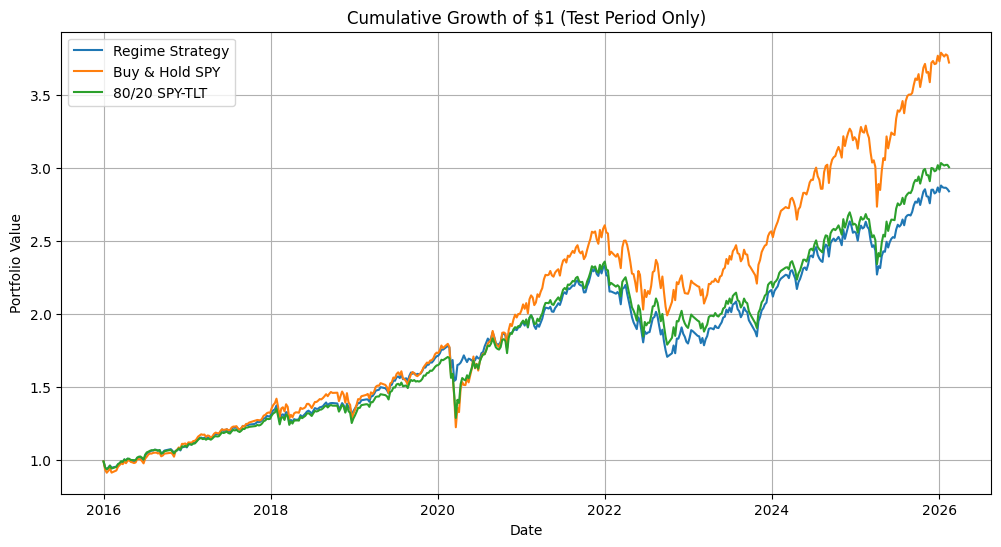

In [15]:
# growth and graphs (test period only)

test_backtest_df = test_backtest_df.copy()

test_backtest_df["strategy_growth"] = cumulative_growth(test_backtest_df["strategy_return"])
test_backtest_df["spy_growth"] = cumulative_growth(test_backtest_df["benchmark_spy"])
test_backtest_df["8020_growth"] = cumulative_growth(test_backtest_df["benchmark_80_20"])

plt.figure(figsize=(12, 6))
plt.plot(test_backtest_df.index, test_backtest_df["strategy_growth"], label="Regime Strategy")
plt.plot(test_backtest_df.index, test_backtest_df["spy_growth"], label="Buy & Hold SPY")
plt.plot(test_backtest_df.index, test_backtest_df["8020_growth"], label="80/20 SPY-TLT")
plt.title("Cumulative Growth of $1 (Test Period Only)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

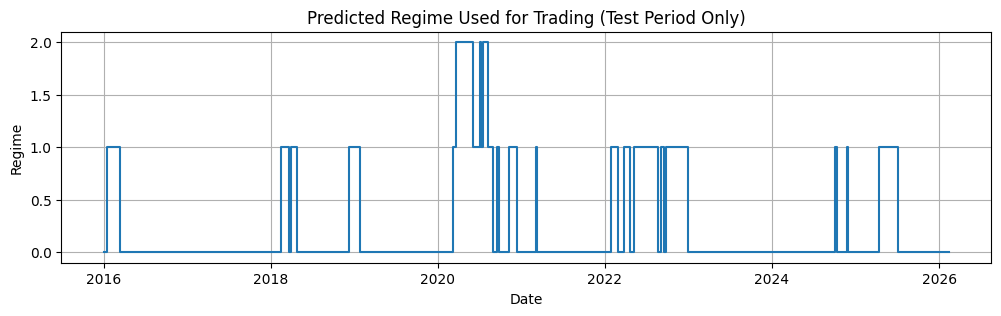

In [16]:
plt.figure(figsize=(12, 3))
plt.plot(test_backtest_df.index, test_backtest_df["signal_regime"], drawstyle="steps-post")
plt.title("Predicted Regime Used for Trading (Test Period Only)")
plt.xlabel("Date")
plt.ylabel("Regime")
plt.grid(True)
plt.show()

In [17]:
price_cols = {
    "SPY": "SP500_SPY",
    "QQQ": "NASDAQ100_QQQ",
    "TLT": "TREASURY_BOND_TLT",
    "GLD": "GOLD_GLD",
    "XLE": "ENERGY_XLE",
    "XLK": "TECH_XLK",
    "XLU": "UTILITIES_XLU",
    "XLP": "CONSUMER_STAPLES_XLP",
    "XLV": "HEALTHCARE_XLV",
    "XLF": "FINANCIALS_XLF"
}


allocation_map_a = {
    0: {"SPY": 0.60, "QQQ": 0.20, "TLT": 0.20, "GLD": 0.00},
    1: {"SPY": 0.30, "QQQ": 0.20, "TLT": 0.30, "GLD": 0.20},
    2: {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}

allocation_map_b = {
    0: {"SPY": 0.70, "QQQ": 0.20, "TLT": 0.10, "GLD": 0.00},
    1: {"SPY": 0.50, "QQQ": 0.00, "TLT": 0.30, "GLD": 0.20},
    2: {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}

allocation_map_c = {
    0: {"SPY": 0.40, "QQQ": 0.20, "XLK": 0.20, "XLE": 0.10, "TLT": 0.10},  
    1: {"TLT": 0.30, "GLD": 0.20, "XLU": 0.35, "XLP": 0.15},
    2: {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},            
}

allocation_map_d = {
    0: {"SPY": 0.50, "QQQ": 0.20, "XLK": 0.20, "TLT": 0.10},
    1: {"TLT": 0.10, "GLD": 0.50, "XLU": 0.15, "XLP": 0.10, "XLV": 0.15},
    2: {"SPY": 0.10, "QQQ": 0.00, "TLT": 0.70, "GLD": 0.20},
}



In [18]:
returns_df = pd.DataFrame(index=combined_weekly.index)

for asset_name, col in price_cols.items():
    if col in combined_weekly.columns:
        returns_df[f"{asset_name}_return"] = combined_weekly[col].pct_change()
    else:
        print(f"Warning: {col} not found in combined_weekly")

print("\nReturns df tail:")
print(returns_df.tail())


Returns df tail:
            SPY_return  QQQ_return  TLT_return  GLD_return  XLE_return  \
2026-03-06   -0.019840   -0.012416   -0.022747   -0.021168    0.011624   
2026-03-13   -0.015006   -0.010054   -0.021705   -0.026758    0.019975   
2026-03-20   -0.018042   -0.019639   -0.008204   -0.102986    0.027903   
2026-03-27   -0.022326   -0.032249   -0.002214    0.003193    0.054797   
2026-04-03    0.034285    0.039816    0.017478    0.035471   -0.046721   

            XLK_return  XLU_return  XLP_return  XLV_return  XLF_return  
2026-03-06   -0.010594   -0.020742   -0.046995   -0.046816   -0.016722  
2026-03-13   -0.003569    0.004707   -0.012124   -0.019057   -0.033221  
2026-03-20   -0.011038   -0.049191   -0.040713   -0.029775    0.003886  
2026-03-27   -0.039692    0.021053    0.006028   -0.014243   -0.025876  
2026-04-03    0.048023    0.023557    0.006981    0.028993    0.041301  


In [19]:
aligned_returns = returns_df[["TLT_return", "GLD_return", "XLE_return", "XLK_return","XLU_return","XLP_return","XLV_return", "XLF_return"]].tail(len(model_df)).reset_index(drop=True)
aligned_model = model_df.reset_index(drop=True)

backtest_df = model_df.join(
    returns_df[["TLT_return", "GLD_return", "XLE_return", "XLK_return", "XLU_return", "XLP_return", "XLV_return", "XLF_return"]],
    how="inner"
)

backtest_df = backtest_df.dropna(subset=["SPY_return", "QQQ_return", "TLT_return"]).copy()

print("\nBacktest df shape:", backtest_df.shape)
# print(backtest_df.head())




Backtest df shape: (1054, 23)


In [20]:
backtest_df["signal_regime"] = backtest_df["predicted_regime"].shift(1)
backtest_df = backtest_df.dropna(subset = ["signal_regime"]).copy()
backtest_df["signal_regime"] = backtest_df['signal_regime'].astype(int)



In [21]:
print(backtest_df.filter(like="w_").head())



Empty DataFrame
Columns: []
Index: [2004-12-03 00:00:00, 2004-12-10 00:00:00, 2004-12-17 00:00:00, 2004-12-24 00:00:00, 2004-12-31 00:00:00]


In [22]:
def run_allocation_backtest(base_df, allocation_map, benchmark_spy_col="SPY_return", benchmark_tlt_col="TLT_return"):
    df = base_df.copy()

    cols_to_drop = [c for c in df.columns if c.startswith("w_")] + [
        "strategy_return", "benchmark_spy", "benchmark_80_20",
        "strategy_growth", "spy_growth", "8020_growth"
    ]
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    def get_weights(regime):
        if regime not in allocation_map:
            raise ValueError(f"Regime {regime} not found in allocation map")
        return allocation_map[regime]

    weights_df = df["signal_regime"].map(get_weights).apply(pd.Series).fillna(0.0)
    weights_df = weights_df.add_prefix("w_").reset_index(drop=True)

    df = df.reset_index(drop=True)
    df = pd.concat([df, weights_df], axis=1)

    for asset in weights_df.columns:
        asset_name = asset.replace("w_", "")
        return_col = f"{asset_name}_return"
        if return_col not in df.columns:
            df[return_col] = 0.0
        else:
            df[return_col] = df[return_col].fillna(0.0)

    weight_cols = list(weights_df.columns)
    weight_sums = df[weight_cols].sum(axis=1)
    if not np.allclose(weight_sums, 1.0):
        print("Warning: some regime weights do not sum to 1.0")
        print(weight_sums.value_counts())

    df["strategy_return"] = 0.0
    for col in weight_cols:
        asset_name = col.replace("w_", "")
        df["strategy_return"] += df[col] * df[f"{asset_name}_return"]

    df["benchmark_spy"] = df[benchmark_spy_col]
    df["benchmark_80_20"] = 0.80 * df[benchmark_spy_col] + 0.20 * df[benchmark_tlt_col]

    summary = pd.DataFrame([
        summarize_performance(df["strategy_return"], "Regime Strategy"),
        summarize_performance(df["benchmark_spy"], "Buy & Hold SPY"),
        summarize_performance(df["benchmark_80_20"], "80/20 SPY-TLT")
    ])

    return df, summary

    

In [23]:
results = {}

for name, alloc in {
    "Current": allocation_map_a,
    "Aggressive Bull": allocation_map_b,
    "Sector Tilt": allocation_map_c,
    "Defensive Rotation": allocation_map_d
}.items():
    bt_df, summary = run_allocation_backtest(backtest_df, alloc)
    summary["Test"] = name
    results[name] = (bt_df, summary)

comparison = pd.concat([results[name][1] for name in results], ignore_index=True)
print(comparison)



           Strategy  Annualized Return  Annualized Volatility  Sharpe Ratio  \
0   Regime Strategy           0.121730               0.110245      1.104180   
1    Buy & Hold SPY           0.121030               0.170142      0.711346   
2     80/20 SPY-TLT           0.110832               0.131805      0.840875   
3   Regime Strategy           0.121733               0.118902      1.023810   
4    Buy & Hold SPY           0.121030               0.170142      0.711346   
5     80/20 SPY-TLT           0.110832               0.131805      0.840875   
6   Regime Strategy           0.117880               0.122720      0.960562   
7    Buy & Hold SPY           0.121030               0.170142      0.711346   
8     80/20 SPY-TLT           0.110832               0.131805      0.840875   
9   Regime Strategy           0.126031               0.126844      0.993595   
10   Buy & Hold SPY           0.121030               0.170142      0.711346   
11    80/20 SPY-TLT           0.110832              

In [24]:
asset_returns = backtest_df[[
    "SPY_return", "QQQ_return", "TLT_return", "GLD_return",
    "XLE_return", "XLK_return", "XLU_return", "XLP_return", "XLV_return", "XLF_return"
]].copy()

In [25]:
train_bt = backtest_df.loc[backtest_df.index <= X_train.index.max()].copy()

In [26]:
def build_dynamic_allocation_map(train_df, regime_col="signal_regime", asset_cols=None, top_n=4):
    if asset_cols is None:
        asset_cols = [
            "SPY_return", "QQQ_return", "TLT_return", "GLD_return",
            "XLE_return", "XLK_return", "XLU_return", "XLP_return",
            "XLV_return", "XLF_return"
        ]

    allocation_map = {}

    for regime in sorted(train_df[regime_col].dropna().unique()):
        regime_slice = train_df[train_df[regime_col] == regime]

        scores = {}
        for col in asset_cols:
            series = regime_slice[col].dropna()
            if len(series) < 10:
                scores[col] = 0.0
                continue

            mean_ret = series.mean()
            vol = series.std()

            if vol == 0 or np.isnan(vol):
                score = 0.0
            else:
                score = mean_ret / vol

            scores[col] = max(score, 0.0)

        score_series = pd.Series(scores).sort_values(ascending=False)

        # keep only top N positive-score assets
        score_series = score_series[score_series > 0].head(top_n)

        if len(score_series) == 0:
            weights = {
                "SPY": 0.25,
                "QQQ": 0.25,
                "TLT": 0.25,
                "GLD": 0.25
            }
        else:
            weights = (score_series / score_series.sum()).to_dict()
            weights = {k.replace("_return", ""): v for k, v in weights.items()}

        allocation_map[int(regime)] = weights

    return allocation_map

In [27]:
dynamic_allocation_map = build_dynamic_allocation_map(train_bt)

print(dynamic_allocation_map)

{0: {'XLV': 0.29242602914542826, 'XLP': 0.27140404073314933, 'XLU': 0.2244913413699886, 'SPY': 0.2116785887514338}, 1: {'XLP': 0.3356860094669718, 'QQQ': 0.2472768205430924, 'XLK': 0.21660321451067185, 'XLV': 0.20043395547926393}, 2: {'TLT': 0.5697016856071319, 'GLD': 0.43029831439286814}}


In [28]:
def inspect_regime_scores(train_df, regime, regime_col="signal_regime", asset_cols=None):
    if asset_cols is None:
        asset_cols = [
            "SPY_return", "QQQ_return", "TLT_return", "GLD_return",
            "XLE_return", "XLK_return", "XLU_return", "XLP_return",
            "XLV_return", "XLF_return"
        ]

    regime_slice = train_df[train_df[regime_col] == regime]
    rows = []

    for col in asset_cols:
        series = regime_slice[col].dropna()
        mean_ret = series.mean()
        vol = series.std()
        score = 0.0 if (vol == 0 or np.isnan(vol)) else mean_ret / vol

        rows.append({
            "asset": col.replace("_return", ""),
            "mean_return": mean_ret,
            "volatility": vol,
            "score": score
        })

    return pd.DataFrame(rows).sort_values("score", ascending=False)

In [29]:
print(inspect_regime_scores(train_bt, regime=0))
print(inspect_regime_scores(train_bt, regime=1))
print(inspect_regime_scores(train_bt, regime=2))

  asset  mean_return  volatility     score
8   XLV     0.002751    0.015458  0.177979
7   XLP     0.002221    0.013445  0.165184
6   XLU     0.002459    0.018000  0.136632
0   SPY     0.002085    0.016184  0.128834
1   QQQ     0.002280    0.020980  0.108674
5   XLK     0.001901    0.020006  0.095021
2   TLT     0.001462    0.016179  0.090394
4   XLE     0.002379    0.028735  0.082776
9   XLF     0.001683    0.020957  0.080303
3   GLD     0.000921    0.023072  0.039906
  asset  mean_return  volatility     score
7   XLP     0.003779    0.018020  0.209693
1   QQQ     0.004505    0.029166  0.154466
5   XLK     0.003818    0.028216  0.135305
8   XLV     0.003030    0.024202  0.125205
0   SPY     0.003211    0.027585  0.116406
6   XLU     0.002725    0.024972  0.109111
3   GLD     0.003100    0.030339  0.102177
4   XLE     0.003600    0.039675  0.090740
2   TLT     0.001470    0.021231  0.069215
9   XLF     0.002535    0.047315  0.053580
  asset  mean_return  volatility     score
2   TLT    

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=059a5e93-4459-411b-9a58-2a578fd7a892' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>